# Data Mining Assignment 2 – Recommender Systems

#### TOPRAK GURSOY / 20259333

Two recommendation models are implemented and evaluated:
1. **User-Based Collaborative Filtering** (KNNWithMeans, surprise)
2. **Matrix Factorization – SVD** (surprise)

Metrics: RMSE (5-fold CV), Precision@10, Recall@10

## 1. Imports & Setup

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from surprise import Dataset, Reader, KNNWithMeans, SVD
from surprise.model_selection import cross_validate, train_test_split
from surprise import accuracy
from collections import defaultdict

np.random.seed(42)
sns.set_theme(style="whitegrid")
print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Load Data & Exploratory Data Analysis

In [3]:
movies  = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings_train.csv')
test_df = pd.read_csv('ratings_test.csv')

print("=== movies.csv ===")
print(movies.shape, "\n", movies.head(3))
print("\n=== ratings_train.csv ===")
print(ratings.shape, "\n", ratings.head(3))
print("\n=== Missing values ===")
print("movies:\n", movies.isnull().sum())
print("ratings:\n", ratings.isnull().sum())
print("\nUnique users :", ratings['userId'].nunique())
print("Unique movies:", ratings['movieId'].nunique())
print("Rating range :", ratings['rating'].min(), "–", ratings['rating'].max())

=== movies.csv ===
(9742, 3) 
    movieId                    title  \
0        1         Toy Story (1995)   
1        2           Jumanji (1995)   
2        3  Grumpier Old Men (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  

=== ratings_train.csv ===
(97801, 4) 
    userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224

=== Missing values ===
movies:
 movieId    0
title      0
genres     0
dtype: int64
ratings:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Unique users : 600
Unique movies: 9680
Rating range : 0.5 – 5.0


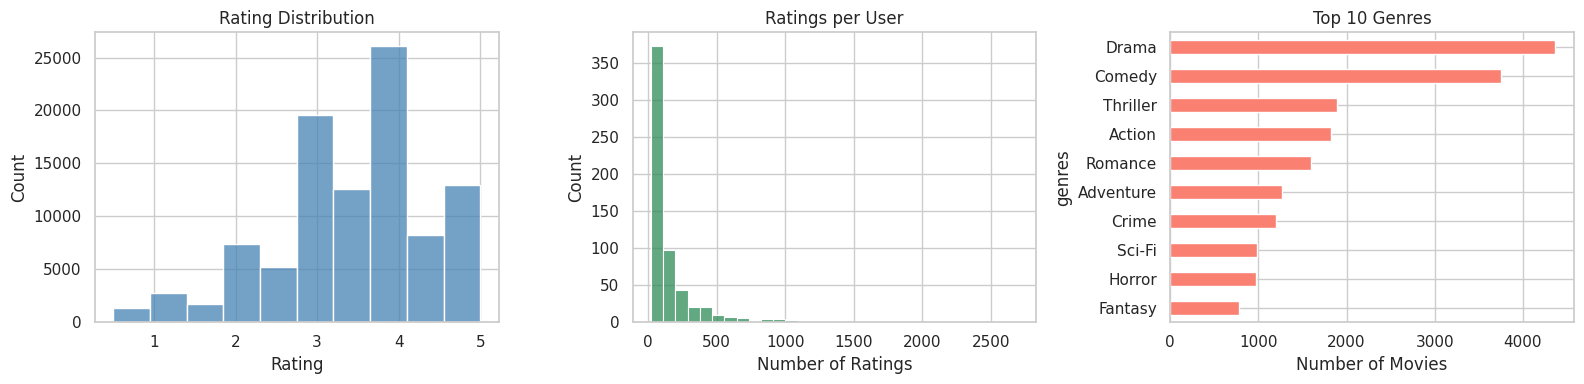

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Rating distribution
sns.histplot(ratings['rating'], bins=10, kde=False, ax=axes[0], color='steelblue')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')

# Ratings per user
ratings_per_user = ratings.groupby('userId').size()
sns.histplot(ratings_per_user, bins=30, kde=False, ax=axes[1], color='seagreen')
axes[1].set_title('Ratings per User')
axes[1].set_xlabel('Number of Ratings')

# Top genres
genre_counts = movies['genres'].str.split('|').explode().value_counts().head(10)
genre_counts.plot(kind='barh', ax=axes[2], color='salmon')
axes[2].set_title('Top 10 Genres')
axes[2].set_xlabel('Number of Movies')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocessing

In [5]:
# Drop duplicates and any rows with NaN ratings
ratings = ratings.dropna(subset=['userId', 'movieId', 'rating']).drop_duplicates()
movies  = movies.dropna(subset=['movieId', 'title'])

# Multi-hot encode genres
all_genres = sorted(set(g for genres in movies['genres'].str.split('|') for g in genres if g != '(no genres listed)'))
for genre in all_genres:
    movies[genre] = movies['genres'].str.contains(genre, regex=False).astype(int)

# Warm vs Cold user check
test_users   = test_df['userId'].tolist()
train_users  = set(ratings['userId'].unique())
warm_users   = [u for u in test_users if u in train_users]
cold_users   = [u for u in test_users if u not in train_users]

print("Test users   :", test_users)
print("Warm users   :", warm_users)
print("Cold users   :", cold_users)

# Build surprise Dataset
reader  = Reader(rating_scale=(ratings['rating'].min(), ratings['rating'].max()))
data    = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

print("\nSurprise dataset ready:", len(ratings), "ratings")

Test users   : [3, 7, 11, 25, 30, 31, 40, 56, 64, 71, 73, 74, 77, 78, 79, 82, 83, 87, 102, 105, 111, 132, 141, 146, 149, 154, 156, 164, 166, 177, 182, 185, 193, 196, 197, 205, 211, 212, 219, 228, 232, 235, 236, 239, 245, 251, 261, 265, 266, 269, 275, 276, 291, 292, 300, 312, 321, 322, 332, 354, 356, 362, 368, 369, 370, 376, 378, 381, 382, 384, 395, 405, 409, 425, 430, 448, 450, 452, 480, 482, 483, 494, 507, 517, 525, 527, 547, 548, 556, 560, 566, 569, 571, 580, 581, 587, 592, 599, 606, 607]
Warm users   : [3, 7, 11, 25, 30, 56, 64, 71, 73, 74, 77, 78, 79, 82, 83, 87, 102, 105, 111, 132, 141, 146, 149, 154, 156, 164, 166, 177, 182, 185, 193, 196, 197, 205, 211, 212, 232, 235, 236, 239, 251, 261, 265, 266, 269, 275, 276, 291, 292, 300, 312, 321, 322, 332, 354, 356, 362, 368, 370, 376, 378, 382, 384, 395, 405, 409, 425, 430, 448, 452, 482, 494, 507, 517, 525, 527, 547, 548, 556, 560, 566, 569, 571, 580, 581, 587, 592, 599, 606, 607]
Cold users   : [31, 40, 219, 228, 245, 369, 381, 450, 48

## 4. Helper Functions (Precision@K, Recall@K)

In [6]:
def precision_recall_at_k(predictions, k=10, threshold=3.5):
    """Compute Precision@K and Recall@K for all users."""
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions, recalls = {}, {}
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel        = sum(1 for (_, true_r) in user_ratings if true_r >= threshold)
        n_rec_k      = sum(1 for (est, _)    in user_ratings[:k] if est  >= threshold)
        n_rel_and_rec_k = sum(1 for (est, true_r) in user_ratings[:k]
                              if true_r >= threshold and est >= threshold)
        precisions[uid] = n_rel_and_rec_k / k if k > 0 else 0
        recalls[uid]    = n_rel_and_rec_k / n_rel if n_rel > 0 else 0

    avg_precision = sum(precisions.values()) / len(precisions)
    avg_recall    = sum(recalls.values())    / len(recalls)
    return avg_precision, avg_recall

print("Helper function defined.")

Helper function defined.


## 5. Model 1 – User-Based Collaborative Filtering (KNNWithMeans)

In [7]:
knn_options = {
    'name': 'cosine',
    'user_based': True
}
knn_model = KNNWithMeans(k=40, sim_options=knn_options)

# 5-fold cross-validation for RMSE
cv_knn = cross_validate(knn_model, data, measures=['RMSE'], cv=5, verbose=False)
knn_rmse_mean = cv_knn['test_rmse'].mean()
knn_rmse_std  = cv_knn['test_rmse'].std()

print(f"User-Based CF  →  RMSE = {knn_rmse_mean:.4f} ± {knn_rmse_std:.4f}")

# Train/test split for Precision@K and Recall@K
trainset_knn, testset_knn = train_test_split(data, test_size=0.2, random_state=42)
knn_model.fit(trainset_knn)
preds_knn      = knn_model.test(testset_knn)
knn_rmse_split = accuracy.rmse(preds_knn, verbose=False)
knn_p10, knn_r10 = precision_recall_at_k(preds_knn, k=10, threshold=3.5)

print(f"Precision@10   = {knn_p10:.4f}")
print(f"Recall@10      = {knn_r10:.4f}")

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
User-Based CF  →  RMSE = 0.9038 ± 0.0045
Computing the cosine similarity matrix...
Done computing similarity matrix.
Precision@10   = 0.5369
Recall@10      = 0.5083


## 6. Model 2 – Matrix Factorization (SVD)

In [8]:
svd_model = SVD(n_factors=100, n_epochs=20, random_state=42)

# 5-fold cross-validation for RMSE
cv_svd = cross_validate(svd_model, data, measures=['RMSE'], cv=5, verbose=False)
svd_rmse_mean = cv_svd['test_rmse'].mean()
svd_rmse_std  = cv_svd['test_rmse'].std()

print(f"SVD  →  RMSE = {svd_rmse_mean:.4f} ± {svd_rmse_std:.4f}")

# Train/test split for Precision@K and Recall@K
trainset_svd, testset_svd = train_test_split(data, test_size=0.2, random_state=42)
svd_model.fit(trainset_svd)
preds_svd      = svd_model.test(testset_svd)
svd_rmse_split = accuracy.rmse(preds_svd, verbose=False)
svd_p10, svd_r10 = precision_recall_at_k(preds_svd, k=10, threshold=3.5)

print(f"Precision@10  = {svd_p10:.4f}")
print(f"Recall@10     = {svd_r10:.4f}")

SVD  →  RMSE = 0.8743 ± 0.0059
Precision@10  = 0.5484
Recall@10     = 0.5134


## 7. Model Comparison & Visualizations

        Model     RMSE  RMSE_std  Precision@10  Recall@10
User-Based CF 0.903811  0.004543      0.536895   0.508263
          SVD 0.874297  0.005925      0.548414   0.513362


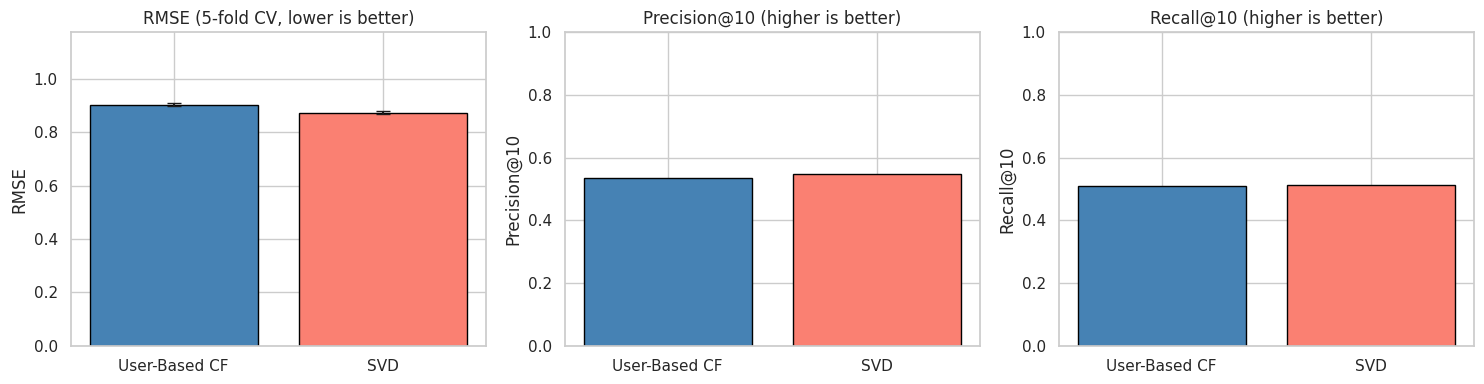

In [9]:
results = pd.DataFrame({
    'Model':        ['User-Based CF', 'SVD'],
    'RMSE':         [knn_rmse_mean, svd_rmse_mean],
    'RMSE_std':     [knn_rmse_std,  svd_rmse_std],
    'Precision@10': [knn_p10,       svd_p10],
    'Recall@10':    [knn_r10,       svd_r10],
})
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# RMSE comparison with error bars
axes[0].bar(results['Model'], results['RMSE'],
            yerr=results['RMSE_std'], capsize=5,
            color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('RMSE (5-fold CV, lower is better)')
axes[0].set_ylabel('RMSE')
axes[0].set_ylim(0, results['RMSE'].max() * 1.3)

# Precision@10
axes[1].bar(results['Model'], results['Precision@10'],
            color=['steelblue', 'salmon'], edgecolor='black')
axes[1].set_title('Precision@10 (higher is better)')
axes[1].set_ylabel('Precision@10')
axes[1].set_ylim(0, 1)

# Recall@10
axes[2].bar(results['Model'], results['Recall@10'],
            color=['steelblue', 'salmon'], edgecolor='black')
axes[2].set_title('Recall@10 (higher is better)')
axes[2].set_ylabel('Recall@10')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Generate Test Recommendations (Task 2)

In [10]:
# Re-train best model (SVD) on full training data
full_trainset = data.build_full_trainset()
best_model = SVD(n_factors=100, n_epochs=20, random_state=42)
best_model.fit(full_trainset)

all_movie_ids = movies['movieId'].tolist()

# Popularity fallback: top-100 most rated movies for cold-start users
movie_popularity = (ratings.groupby('movieId')['rating']
                    .agg(['count', 'mean'])
                    .sort_values(['count', 'mean'], ascending=False))
popular_movies = movie_popularity.index.tolist()

def get_top_k_recs(model, user_id, rated_movies, all_movies, k=10):
    """Predict ratings for all unseen movies and return top-K."""
    unseen = [m for m in all_movies if m not in rated_movies]
    preds  = [model.predict(user_id, m) for m in unseen]
    preds.sort(key=lambda x: x.est, reverse=True)
    return [p.iid for p in preds[:k]]

recommendations = {}

for user_id in test_users:
    if user_id in warm_users:
        # Warm user: personalised SVD recommendations
        rated = set(ratings[ratings['userId'] == user_id]['movieId'].tolist())
        recs  = get_top_k_recs(best_model, user_id, rated, all_movie_ids, k=10)
    else:
        # Cold-start: top-10 globally popular movies
        recs = popular_movies[:10]
    recommendations[user_id] = recs
    print(f"User {user_id} ({'warm' if user_id in warm_users else 'cold'}): {recs}")

print("\nRecommendations generated.")

User 3 (warm): [1265, 1213, 32, 62, 4874, 6377, 246, 3200, 58559, 906]
User 7 (warm): [858, 1221, 926, 1203, 1198, 78499, 112552, 908, 527, 318]
User 11 (warm): [2571, 260, 1204, 1198, 1136, 1213, 899, 858, 912, 750]
User 25 (warm): [50, 296, 318, 356, 608, 750, 858, 898, 908, 912]
User 30 (warm): [50, 750, 858, 1197, 1225, 1258, 2329, 2959, 3147, 3435]
User 31 (cold): [356, 318, 296, 593, 2571, 260, 480, 110, 589, 527]
User 40 (cold): [356, 318, 296, 593, 2571, 260, 480, 110, 589, 527]
User 56 (warm): [1104, 5971, 904, 750, 1262, 1204, 1223, 858, 4011, 1089]
User 64 (warm): [750, 1104, 1261, 898, 3451, 5618, 1223, 475, 904, 38061]
User 71 (warm): [318, 110, 7361, 1104, 2324, 50, 1213, 527, 1258, 2804]
User 73 (warm): [1276, 527, 17, 928, 50, 293, 745, 1148, 4973, 318]
User 74 (warm): [1104, 318, 3037, 750, 1228, 1248, 1213, 1237, 5618, 922]
User 77 (warm): [1204, 50, 1201, 1197, 2019, 1249, 142488, 3468, 1219, 6711]
User 78 (warm): [1213, 858, 110, 1242, 778, 2324, 1089, 898, 1221, 12

## 9. Fill & Save ratings_test.csv

In [11]:
rec_cols = [f'recommendation{i}' for i in range(1, 11)]
output   = pd.read_csv('ratings_test.csv')

for idx, row in output.iterrows():
    uid  = row['userId']
    recs = recommendations.get(uid, popular_movies[:10])
    for i, col in enumerate(rec_cols):
        output.at[idx, col] = int(recs[i])

output[rec_cols] = output[rec_cols].astype(int)
output.to_csv('ratings_test.csv', index=False)

print("ratings_test.csv updated successfully!")
print(output.to_string(index=False))

ratings_test.csv updated successfully!
 userId  recommendation1  recommendation2  recommendation3  recommendation4  recommendation5  recommendation6  recommendation7  recommendation8  recommendation9  recommendation10
      3             1265             1213               32               62             4874             6377              246             3200            58559               906
      7              858             1221              926             1203             1198            78499           112552              908              527               318
     11             2571              260             1204             1198             1136             1213              899              858              912               750
     25               50              296              318              356              608              750              858              898              908               912
     30               50              750              858        